In [8]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import os
import geopandas as gpd
import rioxarray
import hvplot.xarray 
import pandas as pd
import numpy as np

from rasterio.mask import mask
from concurrent.futures import ProcessPoolExecutor
import rasterio
from exactextract import exact_extract
from shapely.geometry import shape

In [2]:
# # !mkdir -p /inputs/CHIRPS
# !wget "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/final/rnl/1981/chirps-v3.0.rnl.1981.01.01.tif"

In [3]:
path_shapefiles = Path('../caravan_shapefiles/camels')
basins_txt_file = Path('../basins_without_snow.txt')

In [4]:
gdf = gpd.read_file(path_shapefiles / 'camels_basin_shapes.shp')
gdf.head()

,gauge_id,geometry
0,camels_01013500,"MULTIPOLYGON (((-68.06259 47.17901, -68.06028 ..."
1,camels_01022500,"POLYGON ((-67.97836 44.6131, -67.98141 44.6143..."
2,camels_01030500,"MULTIPOLYGON (((-68.09162 46.11477, -68.08453 ..."
3,camels_01031500,"MULTIPOLYGON (((-69.31629 45.15325, -69.32144 ..."
4,camels_01047000,"POLYGON ((-70.10847 45.21669, -70.10609 45.213..."


In [5]:
with open(basins_txt_file) as f:
    selected_basins = [line.strip() for line in f.readlines()]

selected_basins


['camels_01411300',
 'camels_01487000',
 'camels_01491000',
 'camels_01644000',
 'camels_01664000',
 'camels_01667500',
 'camels_02028500',
 'camels_02051500',
 'camels_02053200',
 'camels_02053800',
 'camels_02056900',
 'camels_02059500',
 'camels_02069700',
 'camels_02070000',
 'camels_02074500',
 'camels_02077200',
 'camels_02081500',
 'camels_02092500',
 'camels_02096846',
 'camels_02102908',
 'camels_02111180',
 'camels_02111500',
 'camels_02112120',
 'camels_02112360',
 'camels_02118500',
 'camels_02125000',
 'camels_02128000',
 'camels_02137727',
 'camels_02140991',
 'camels_02143000',
 'camels_02143040',
 'camels_02149000',
 'camels_02152100',
 'camels_02177000',
 'camels_02178400',
 'camels_02193340',
 'camels_02196000',
 'camels_02202600',
 'camels_02212600',
 'camels_02215100',
 'camels_02216180',
 'camels_02221525',
 'camels_02231000',
 'camels_02246000',
 'camels_02296500',
 'camels_02297155',
 'camels_02297310',
 'camels_02298123',
 'camels_02298608',
 'camels_02299950',


In [16]:
gauge = "camels_02152100"

In [17]:
basin = gdf[gdf['gauge_id'] == gauge]
basin

,gauge_id,geometry
133,camels_02152100,"POLYGON ((-81.75412 35.6119, -81.75036 35.6103..."


In [15]:
basins_gdf = gdf[gdf['gauge_id'].isin(selected_basins)]
basins_gdf

,gauge_id,geometry
31,camels_01411300,"POLYGON ((-74.82836 39.38169, -74.83051 39.379..."
46,camels_01487000,"MULTIPOLYGON (((-75.51965 38.87137, -75.51541 ..."
47,camels_01491000,"MULTIPOLYGON (((-75.62847 39.00272, -75.62813 ..."
82,camels_01644000,"POLYGON ((-77.79457 39.16487, -77.78732 39.159..."
84,camels_01664000,"POLYGON ((-78.02404 38.89586, -78.01963 38.893..."
...,...,...
477,camels_08200000,"MULTIPOLYGON (((-99.24583 29.56851, -99.24428 ..."
478,camels_08202700,"POLYGON ((-99.43663 29.73943, -99.43192 29.738..."
510,camels_09484600,"MULTIPOLYGON (((-110.81922 31.90117, -110.8185..."
547,camels_11124500,"POLYGON ((-119.81038 34.71319, -119.79876 34.7..."


In [10]:
ds = xr.open_dataset("/inputs/CHIRPS/chirps-v3.0.rnl.1981.01.01.tif")
ds

<xarray.Dataset> Size: 69MB
Dimensions:      (band: 1, x: 7200, y: 2400)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * y            (y) float64 19kB 59.97 59.92 59.87 ... -59.88 -59.93 -59.98
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 69MB ...

In [11]:
precip = ds["band_data"].isel(band=0)
precip

<xarray.DataArray 'band_data' (y: 2400, x: 7200)> Size: 69MB
[17280000 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * y            (y) float64 19kB 59.97 59.92 59.87 ... -59.88 -59.93 -59.98
    spatial_ref  int64 8B ...
Attributes:
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/daily/ERA5/1981/chirps-v3.0....
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:01:07 14:33:54
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    TIFFTAG_RESOLUTIONUNIT:    2 (pixels/inch)
    AREA_OR_POINT:             Area

In [12]:
precip = precip.where(precip != -9999, np.nan)

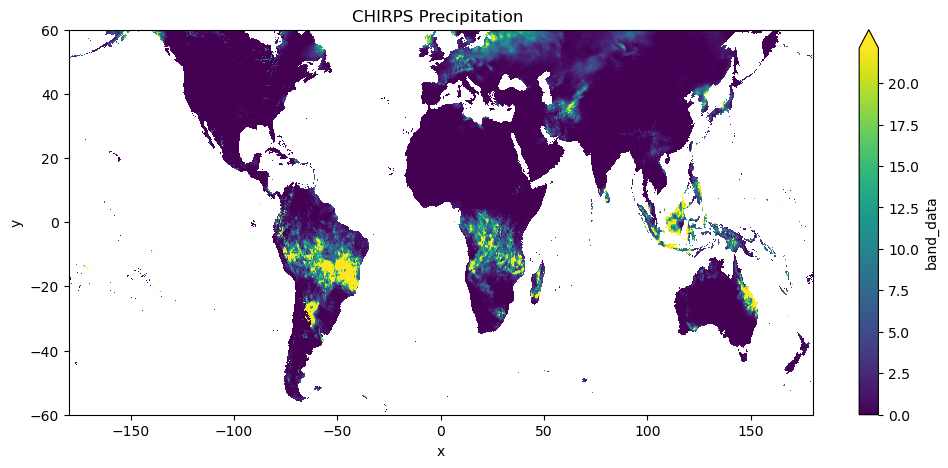

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(12,5))
precip.plot(
    ax=ax,
    x="x",
    y="y",
    cmap="viridis",
    # vmin=0, vmax=30,
    robust=True  # avoids extreme outliers messing up colors
)

# Use the filename or date from attributes since there is no time coordinate
ax.set_title(f"CHIRPS Precipitation {ds.attrs.get('TIFFTAG_DOCUMENTNAME','')}")
plt.show()

In [ ]:
# Set the CRS on the DataArray (CHIRPS is in WGS84)
precip = precip.rio.write_crs("EPSG:4326")

# Make sure basin has the same CRS
basin = basin.to_crs("EPSG:4326")

# Clip
precip_clipped = precip.rio.clip(basin.geometry, basin.crs)
precip_clipped

<xarray.DataArray 'band_data' (y: 2, x: 3)> Size: 24B
array([[nan,  0.,  0.],
       [ 0.,  0.,  0.]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 24B -81.82 -81.77 -81.72
  * y            (y) float64 16B 35.57 35.52
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/daily/ERA5/1981/chirps-v3.0....
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:01:07 14:33:54
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    TIFFTAG_RESOLUTIONUNIT:    2 (pixels/inch)
    AREA_OR_POINT:             Area

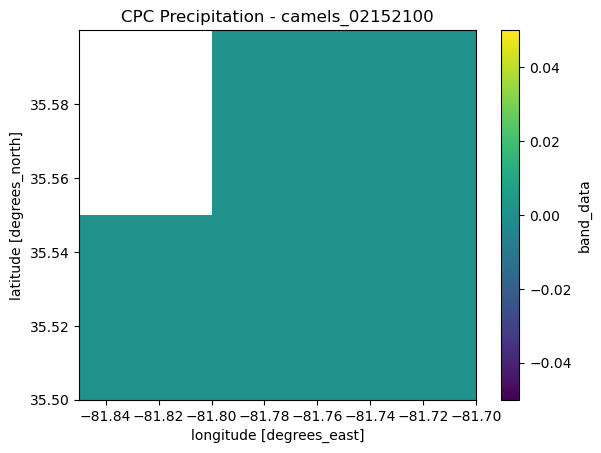

In [16]:
precip_clipped.plot(cmap="viridis", robust=True)
plt.title(f"CPC Precipitation - {gauge}")
plt.show()

# Creating the timeseries

In [21]:
# --- Function to process one file for a basin ---
def process_file(file_path, geometries):
    # Extract date from filename: chirps-v3.0.rnl.1981.01.01.tif
    parts = file_path.stem.split('.')
    date_str = parts[-3:]  # ['1981', '01', '01']
    date = pd.to_datetime('-'.join(date_str))

    with rasterio.open(file_path) as src:
        out_image, _ = mask(src, geometries, crop=True, filled=True, nodata=np.nan)
        precip_band = out_image[0].astype(float)
        precip_band[precip_band == -9999] = np.nan
        value = np.nanmean(precip_band)

    return date, value

# --- Setup ---
chirps_files = sorted(Path("/inputs/CHIRPS_v3/").glob("chirps-v3.0.rnl.*.tif"))

gauge = "camels_02152100"
basin = gdf[gdf['gauge_id'] == gauge].to_crs("EPSG:4326")
geometries = list(basin.geometry)  # list of shapely geometries for rasterio

# output_dir = Path("/outputs/")
# output_dir.mkdir(exist_ok=True)
output_dir = Path('./precip_timeseries_chirpsv3')
output_dir.mkdir(exist_ok=True)

# --- Parallel processing ---
all_ts = []
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_file, f, geometries) for f in chirps_files]
    for i, future in enumerate(futures, 1):
        date, value = future.result()
        all_ts.append((date, value))
        print(f"{gauge} - {date.date()} processed ({i}/{len(chirps_files)})")

# --- Build and save DataFrame ---
full_ts = pd.Series(
    data=[v for _, v in all_ts],
    index=[d for d, _ in all_ts],
    name="precipitation"
).sort_index()

output_file = output_dir / f"{gauge}_precip.csv"
full_ts.to_csv(output_file)
print(f"Saved {output_file}")

camels_02152100 - 1989-01-01 processed (1/11322)
camels_02152100 - 1989-01-02 processed (2/11322)
camels_02152100 - 1989-01-03 processed (3/11322)
camels_02152100 - 1989-01-04 processed (4/11322)
camels_02152100 - 1989-01-05 processed (5/11322)
camels_02152100 - 1989-01-06 processed (6/11322)
camels_02152100 - 1989-01-07 processed (7/11322)
camels_02152100 - 1989-01-08 processed (8/11322)
camels_02152100 - 1989-01-09 processed (9/11322)
camels_02152100 - 1989-01-10 processed (10/11322)
camels_02152100 - 1989-01-11 processed (11/11322)
camels_02152100 - 1989-01-12 processed (12/11322)
camels_02152100 - 1989-01-13 processed (13/11322)
camels_02152100 - 1989-01-14 processed (14/11322)
camels_02152100 - 1989-01-15 processed (15/11322)
camels_02152100 - 1989-01-16 processed (16/11322)
camels_02152100 - 1989-01-17 processed (17/11322)
camels_02152100 - 1989-01-18 processed (18/11322)
camels_02152100 - 1989-01-19 processed (19/11322)
camels_02152100 - 1989-01-20 processed (20/11322)
camels_02

In [33]:
# ALL US BASINS

In [6]:
basins_gdf = gdf[gdf['gauge_id'].isin(selected_basins)].to_crs("EPSG:4326")
basins_gdf

# store geometries per basin
basin_geoms = {
    row['gauge_id']: [row.geometry]
    for _, row in basins_gdf.iterrows()
}

In [7]:
basin_geoms

{'camels_01411300': [<POLYGON ((-74.828 39.382, -74.831 39.379, -74.838 39.378, -74.841 39.373, -...>],
 'camels_01487000': [<MULTIPOLYGON (((-75.52 38.871, -75.515 38.871, -75.513 38.869, -75.514 38.8...>],
 'camels_01491000': [<MULTIPOLYGON (((-75.628 39.003, -75.628 39.003, -75.628 39.002, -75.629 39....>],
 'camels_01644000': [<POLYGON ((-77.795 39.165, -77.787 39.16, -77.784 39.161, -77.778 39.159, -7...>],
 'camels_01664000': [<POLYGON ((-78.024 38.896, -78.02 38.894, -78.018 38.891, -78.008 38.886, -7...>],
 'camels_01667500': [<POLYGON ((-78.372 38.598, -78.369 38.592, -78.366 38.592, -78.361 38.586, -...>],
 'camels_02028500': [<POLYGON ((-78.841 38.046, -78.835 38.042, -78.833 38.035, -78.826 38.029, -...>],
 'camels_02051500': [<MULTIPOLYGON (((-78.176 36.762, -78.176 36.762, -78.176 36.762, -78.176 36....>],
 'camels_02053200': [<MULTIPOLYGON (((-77.008 36.366, -77.012 36.365, -77.013 36.361, -77.01 36.3...>],
 'camels_02053800': [<MULTIPOLYGON (((-80.103 37.164, -80.095 37

## Unweighted method

In [ ]:

# -----------------------------------
# 2. FUNCTION: PROCESS ONE FILE
# -----------------------------------
def process_file_all_basins(file_path, basin_geoms):
    parts = file_path.stem.split('.')
    date = pd.to_datetime('-'.join(parts[-3:]))

    results = {}

    with rasterio.open(file_path) as src:
        for gauge, geometries in basin_geoms.items():
            out_image, _ = mask(src, geometries, crop=True, filled=True, nodata=np.nan)

            band = out_image[0].astype(float)
            band[band == -9999] = np.nan

            results[gauge] = np.nanmean(band)

    return date, results

# -----------------------------------
# 3. INPUT FILES
# -----------------------------------
chirps_files = sorted(Path("/inputs/CHIRPS_v3/").glob("chirps-v3.0.rnl.*.tif"))

# -----------------------------------
# 4. PARALLEL EXECUTION
# -----------------------------------
all_results = []

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_file_all_basins, f, basin_geoms) for f in chirps_files]

    for i, future in enumerate(futures, 1):
        date, values = future.result()
        all_results.append((date, values))
        print(f"{date.date()} processed ({i}/{len(chirps_files)})")

# -----------------------------------
# 5. REORGANIZE RESULTS
# -----------------------------------
basin_series = {gauge: [] for gauge in basin_geoms.keys()}
dates = []

for date, values in all_results:
    dates.append(date)
    for gauge, val in values.items():
        basin_series[gauge].append(val)

dates = pd.to_datetime(dates)

# -----------------------------------
# 6. SAVE OUTPUTS
# -----------------------------------
output_dir = Path('./precip_timeseries_chirpsv3')
output_dir.mkdir(exist_ok=True)

for gauge, values in basin_series.items():
    ts = pd.Series(values, index=dates, name="precipitation").sort_index()
    output_file = output_dir / f"{gauge}_precip.csv"
    ts.to_csv(output_file)
    print(f"Saved {output_file}")

1989-01-01 processed (1/11322)
1989-01-02 processed (2/11322)
1989-01-03 processed (3/11322)
1989-01-04 processed (4/11322)
1989-01-05 processed (5/11322)
1989-01-06 processed (6/11322)
1989-01-07 processed (7/11322)
1989-01-08 processed (8/11322)
1989-01-09 processed (9/11322)
1989-01-10 processed (10/11322)
1989-01-11 processed (11/11322)
1989-01-12 processed (12/11322)
1989-01-13 processed (13/11322)
1989-01-14 processed (14/11322)
1989-01-15 processed (15/11322)
1989-01-16 processed (16/11322)
1989-01-17 processed (17/11322)
1989-01-18 processed (18/11322)
1989-01-19 processed (19/11322)
1989-01-20 processed (20/11322)
1989-01-21 processed (21/11322)
1989-01-22 processed (22/11322)
1989-01-23 processed (23/11322)
1989-01-24 processed (24/11322)
1989-01-25 processed (25/11322)
1989-01-26 processed (26/11322)
1989-01-27 processed (27/11322)
1989-01-28 processed (28/11322)
1989-01-29 processed (29/11322)
1989-01-30 processed (30/11322)
1989-01-31 processed (31/11322)
1989-02-01 proces

## Weighted method

In [9]:
# -----------------------------------
# 3. INPUT FILES + SETUP
# -----------------------------------
chirps_files = sorted(Path("/inputs/CHIRPS_v3/").glob("chirps-v3.0.rnl.*.tif"))

# Build a single GeoDataFrame with all basins once
gauges = list(basin_geoms.keys())
gdf_all = gpd.GeoDataFrame(
    {"gauge_id": gauges},
    geometry=[geoms[0] for geoms in basin_geoms.values()],  # single geom per basin
    crs="EPSG:4326"
)

# -----------------------------------
# 2. FUNCTION: PROCESS ONE FILE
# -----------------------------------
def process_file_all_basins(file_path, gdf_all, gauges):
    parts = file_path.stem.split('.')
    date = pd.to_datetime('-'.join(parts[-3:]))

    # Single call for ALL basins — file opened once
    result = exact_extract(str(file_path), gdf_all, ["mean"], output="pandas")

    result["mean"] = result["mean"].where(
        (result["mean"] != -9999) & (result["mean"] >= 0), other=np.nan
    )
    results = dict(zip(gauges, result["mean"].values))
    return date, results

# -----------------------------------
# 4. PARALLEL EXECUTION
# -----------------------------------
all_results = []
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_file_all_basins, f, gdf_all, gauges) for f in chirps_files]
    for i, future in enumerate(futures, 1):
        date, values = future.result()
        all_results.append((date, values))
        print(f"{date.date()} processed ({i}/{len(chirps_files)})")

# -----------------------------------
# 5. REORGANIZE RESULTS
# -----------------------------------
basin_series = {gauge: [] for gauge in gauges}
dates = []
for date, values in all_results:
    dates.append(date)
    for gauge, val in values.items():
        basin_series[gauge].append(val)
dates = pd.to_datetime(dates)

# -----------------------------------
# 6. SAVE OUTPUTS
# -----------------------------------
output_dir = Path('./precip_timeseries_chirpsv3_extract')
output_dir.mkdir(exist_ok=True)
for gauge, values in basin_series.items():
    ts = pd.Series(values, index=dates, name="precipitation").sort_index()
    output_file = output_dir / f"{gauge}_precip.csv"
    ts.to_csv(output_file)
    print(f"Saved {output_file}")

1989-01-01 processed (1/11322)
1989-01-02 processed (2/11322)
1989-01-03 processed (3/11322)
1989-01-04 processed (4/11322)
1989-01-05 processed (5/11322)
1989-01-06 processed (6/11322)
1989-01-07 processed (7/11322)
1989-01-08 processed (8/11322)
1989-01-09 processed (9/11322)
1989-01-10 processed (10/11322)
1989-01-11 processed (11/11322)
1989-01-12 processed (12/11322)
1989-01-13 processed (13/11322)
1989-01-14 processed (14/11322)
1989-01-15 processed (15/11322)
1989-01-16 processed (16/11322)
1989-01-17 processed (17/11322)
1989-01-18 processed (18/11322)
1989-01-19 processed (19/11322)
1989-01-20 processed (20/11322)
1989-01-21 processed (21/11322)
1989-01-22 processed (22/11322)
1989-01-23 processed (23/11322)
1989-01-24 processed (24/11322)
1989-01-25 processed (25/11322)
1989-01-26 processed (26/11322)
1989-01-27 processed (27/11322)
1989-01-28 processed (28/11322)
1989-01-29 processed (29/11322)
1989-01-30 processed (30/11322)
1989-01-31 processed (31/11322)
1989-02-01 proces